In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('/kaggle/input/datasets/andrewmvd/trip-advisor-hotel-reviews/tripadvisor_hotel_reviews.csv')
print(df.shape)
df.head()

(20491, 2)


,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


In [3]:
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20491 entries, 0 to 20490
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  20491 non-null  object
 1   Rating  20491 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 320.3+ KB
None

Missing values:
Review    0
Rating    0
dtype: int64


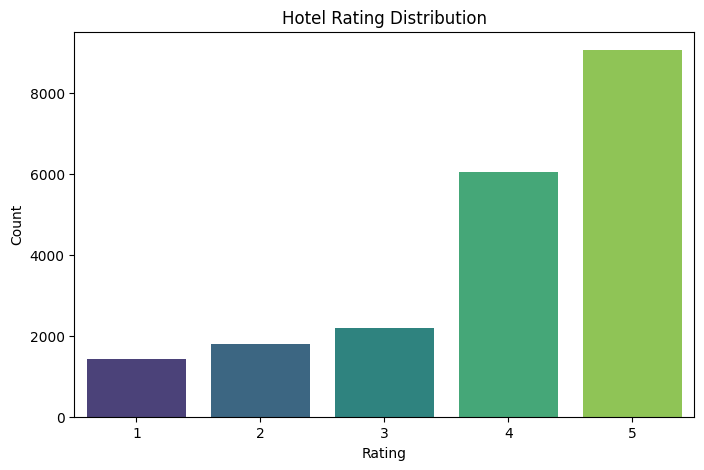

In [4]:
plt.figure(figsize=(8,5))
sns.countplot(x='Rating', data=df, palette='viridis')
plt.title('Hotel Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

In [5]:
df['sentiment'] = df['Review'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
df['sentiment_label'] = df['sentiment'].apply(lambda x: 'Positive' if x > 0 else ('Negative' if x < 0 else 'Neutral'))
df['sentiment_label'].value_counts()

sentiment_label
Positive    19112
Negative     1356
Neutral        23
Name: count, dtype: int64

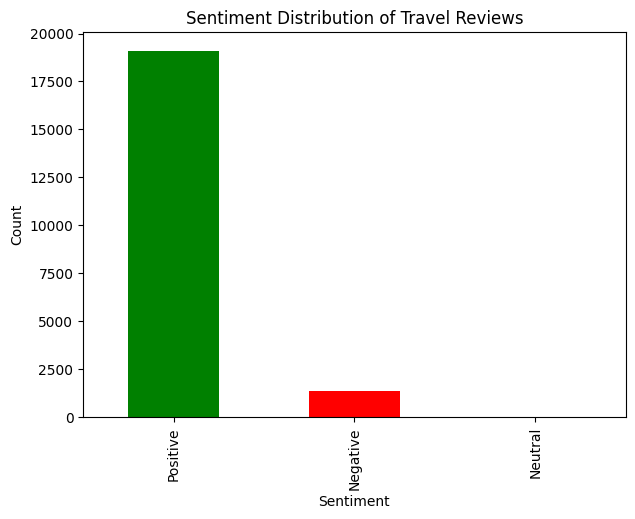

In [6]:
plt.figure(figsize=(7,5))
df['sentiment_label'].value_counts().plot(kind='bar', color=['green','red','gray'])
plt.title('Sentiment Distribution of Travel Reviews')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()